# Previsão de Falhas Estruturais Aplicadas no <span style="color:red;">Motor Brushless</span>

---

### Integrantes do grupo: 
- <span style="color:yellow;">Enrico Magalhães</span>;
-  Hugo Samuel;
- <span style="color:brown;">Vinícius Fernandes</span>;
- <span style="color:green;">Vitor Belo</span>.

---

### Parâmetros do grupo moto-propulsor utilizado: 
(Como contexto e limitação orçamentária desse estudo, destaca-se que nenhum componente foi adquirido para o projeto. Todos os materiais, e inclusive os ensaios, estavam disponíveis e foram realizados na oficina da equipe Trem Ki Voa Micro. O uso gratuito e facilitado desses componetes foi devido à todos os integrantes do grupo serem membros atuais ou ex-integrantes da equipe).

- *Motor:* Scorpion SII-4035-450;
- *Hélice:* Master Airscrew 16×10"× 3;
- *Baterias:* LiFePO4 e LIPO;
- *ESC:* ESCTurnigy® Plush-32 120A HV?????? SERÁ?;
- *Receptor:* FrSky® V8FR-II;
-*Regulador de tensão:* Castle Creations® CCBEC10A.

### Sensores:
- *Allegro® ACS712ELCTR*;
- *Célula de carga*;
- *Arduino UNO*;

---

### Repositório no Github: https://github.com/vitorvespoli/MachineLearning_Trabalho1

---

---


### Definição do problema

A SAE BRASIL é uma associação dedicada ao avanço da engenharia de mobilidade no país. Uma de suas principais iniciativas é o Projeto SAE BRASIL AeroDesign, um programa educacional que desafia estudantes universitários a conceber, projetar, construir e voar aeronaves rádio-controladas, simulando os mesmos desafios enfrentados pela indústria aeronáutica.

Na 26ª Competição SAE Brasil AeroDesign, uma falha no motor impediu o voo da equipe **Trem Ki Voa Micro** (equipe de competição da UFSJ) em uma de suas tentativas oficiais. O evento foi decisivo na pontuação final, resultando na obtenção do vice-campeonato nacional por uma margem de dois pontos em relação ao primeiro colocado.

A partir disso, surgiu a necessidade de desenvolver um modelo capaz de prever falhas com base nos dados de funcionamento do sistema, evitando que falhas passem despercebidas antes de um voo oficial. Dentre as inúmeras falhas que podem interferir no sistema, para a realização desse trabalho, foram escolhidas 3 falhas principais:

- Desbalanceamento de hélice;
- Hélice quebrada;
- Rotação invertida do motor.

<div align="center">
<img src="pics\teste.png" width="1000">
</div>

## Imports:

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statistics as st

### Função para plotar os gráficos

In [117]:
def plot_technical(
    x,
    y,
    title="Título do Gráfico",
    xlabel="Eixo X",
    ylabel="Eixo Y",
    labels=None,
    linewidth=2.0,
    markers=None,
    figsize=(8, 5),
    grid=True,
    save=False,
    filename="grafico.png",
    dpi=300
):
    plt.figure(figsize=figsize)

    # Detecta se y é curva única ou lista de curvas
    if isinstance(y, (pd.Series, np.ndarray, list, tuple)):
        if len(y) > 0 and not isinstance(y[0] if isinstance(y, (list, tuple, np.ndarray)) else y.iloc[0], (list, tuple, np.ndarray, pd.Series)):
            y = [y]
    else:
        y = [y]

    n_curves = len(y)

    if labels is None:
        labels = [f"Curva {i+1}" for i in range(n_curves)]

    if markers is None:
        markers = [None] * n_curves

    for i in range(n_curves):
        plt.plot(
            x,
            y[i],
            label=labels[i],
            linewidth=linewidth,
            marker=markers[i]
        )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.7)

    if labels is not None:
        plt.legend(fontsize=10)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

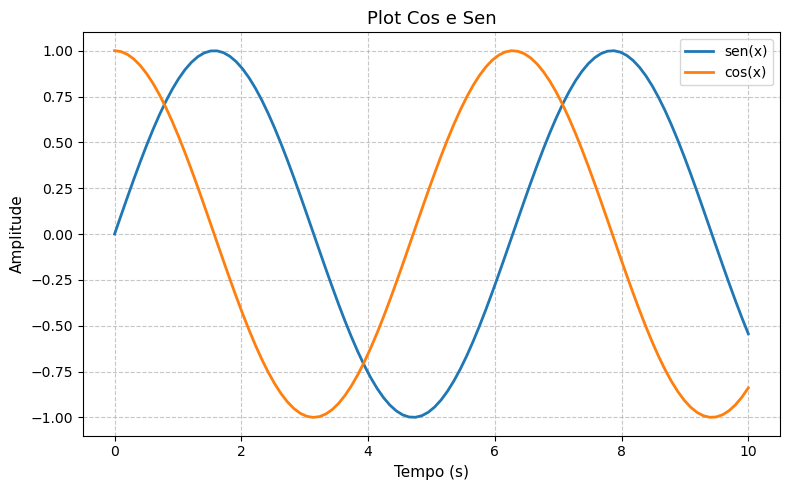

In [118]:
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plot_technical(
    x,
    [y1, y2],
    title="Plot Cos e Sen",
    xlabel="Tempo (s)",
    ylabel="Amplitude",
    labels=["sen(x)", "cos(x)"],
    save=True,
    filename="grafico_1.png"
)

In [119]:
def plot_histogram(
    data,
    bins=30,
    title="Histograma",
    xlabel="Valores",
    ylabel="Frequência",
    figsize=(7,5),
    density=False,
    alpha=0.75,
    grid=True,
    save=False,
    filename="histograma.png",
    dpi=300
):
   

    plt.figure(figsize=figsize)

    plt.hist(
        data,
        bins=bins,
        density=density,
        alpha=alpha,
        edgecolor='black'
    )

    plt.title(title, fontsize=13)
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel(ylabel, fontsize=11)

    if grid:
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

In [120]:
def subplot_histogram(
    dataframe,
    header,
    bins=30,
    title="Histograma",
    xlabel="Valores",
    ylabel="Frequência",
    figsize=(12,8),
    density=False,
    alpha=0.75,
    grid=True,
    save=False,
    filename="histograma.png",
    dpi=300
):
   

    fig, axs = plt.subplots(2,3,figsize=figsize)
    axs = axs.flatten()
    for i, h in enumerate(header):
        axs[i].hist(
            dataframe[h],
            bins=bins,
            density=density,
            alpha=alpha,
            edgecolor='black'
        )
        axs[i].set_title(header[i])
        axs[i].set_xlabel("Valor")
        axs[i].set_ylabel("Frequência")
        axs[i].grid(grid, linestyle=':', alpha=alpha)

    fig.delaxes(axs[5])


    #plt.title(title, fontsize=13)
    #plt.xlabel(xlabel, fontsize=11)
    #plt.ylabel(ylabel, fontsize=11)

    

    plt.tight_layout()

    if save:
        plt.savefig(filename, dpi=dpi, bbox_inches='tight')

    plt.show()

### <span style="color:green;">Diretório dos dados coletados</span>

A seção abaixo foi criada para o armazenamento dos diretórios em que os dados coletados se encontram. Estes são armazenados em um dicionário, sendo possível acessar o diretório de cada operação a partir das chaves definidas ("normal", "desbalanceada", "quebrada", "invertida"). O uso deste dicionário se torna evidente algumas seções à frente.

A variável "thisFolder" é responsável por armazenar o diretório da pasta que o arquivo atual ".ipynb" se encontra. A variável "dataFolder" armazena o diretório da pasta com os dados coletados, a partir da junção dos caminhos provido pela função "os.path.join()". De modo semelhante, as pastas de cada operação são armazenadas nas variáveis "normalFolder", "desbalanceadaFolder", "quebradaFolder" e "invertidaFolder".

In [121]:
# Armazena o diretório de onde o arquivo .ipynb se encontra
thisFolder = os.getcwd()

# Armazena o diretório da pasta com as outras pastas de operações
dataFolder = os.path.join(thisFolder, "dados_coletados")

# Seleciona as pastas de cada operação, separadamente
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

# Um dicionário é criado para acessar cada diretório com uma chave
folders = {
    "normal": normalFolder,
    "desbalanceada": desbalanceadaFolder,
    "quebrada": quebradaFolder,
    "invertida": invertidaFolder
    
}

## <span style="color:green;">Análise Exploratória de Dados</span>
Após a coleta e tratamento dos dados, esses foram segmentados em duas seções de transitórios (transitório inicial e final) e uma seção de regime estacionário, em que o manche do motor permanece no limite máximo, corroborando na tendência de máximo consumo de potência disponível conforme as capacidades do sistema.

A função abaixo realiza a identificação dessas seções. Primeiramente, há a aquisição da média referente aos valores entre 30% e 70% dos dados (seção aproximada de regime permanente), após isso, o algoritmo realiza uma varredura nas linhas dos dados de corrente em Ampères, sendo um dos principais parâmetros que governa o comportamento do sistema, como na potência fornecida e na rotação do motor. A varredura ocorre visando encontrar os pontos de chaveamento de seções. O chaveamento entre o transitório inicial e o regime permanente é quando há o encontro de um dado entre 99 e 130% da média obtida, somando-se 10 posições à esse ponto. Já o chaveamento entre o regime permanente e o transitório final ocorre quando há o encontro de um valor entre 30% e 82% do valor da média obtida, subtraindo 8 posições desse ponto. A busca pelo ponto de chaveamento entre o regime permanente e transitório final ocorre somente se o primeiro ponto de chaveamento já estiver obtido.

Os valores utilizados foram definidos a partir de testes realizados com as bases de dados adquiridas. A adição/subtração de pontos mantém a segmentação mais conservativa, evitando a segmentação de picos ou vales provindos dos transitórios nas seções de regime permanente. 

Ao final do código há um exemplo demonstrando a operação da função de segmentação de seções por meio dos valores normalizados pela média de corrente e tração adquiridos, mostrando que, apesar do uso da corrente como parâmetro de verificação, a relação se estabelece para outras variáveis.

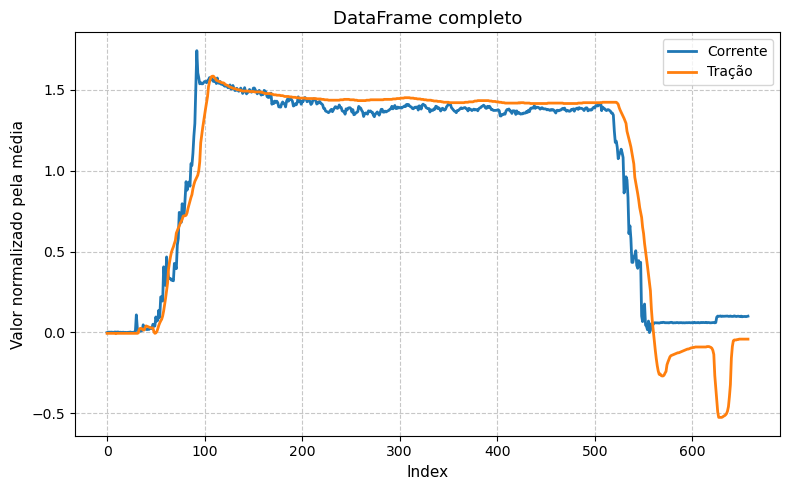

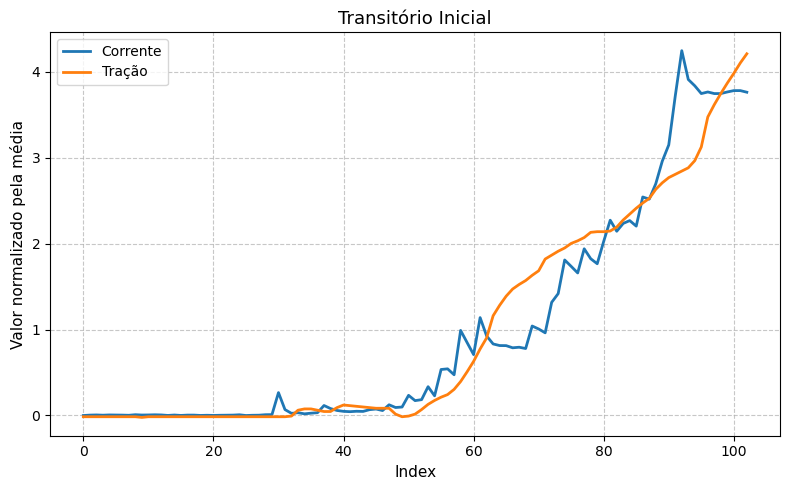

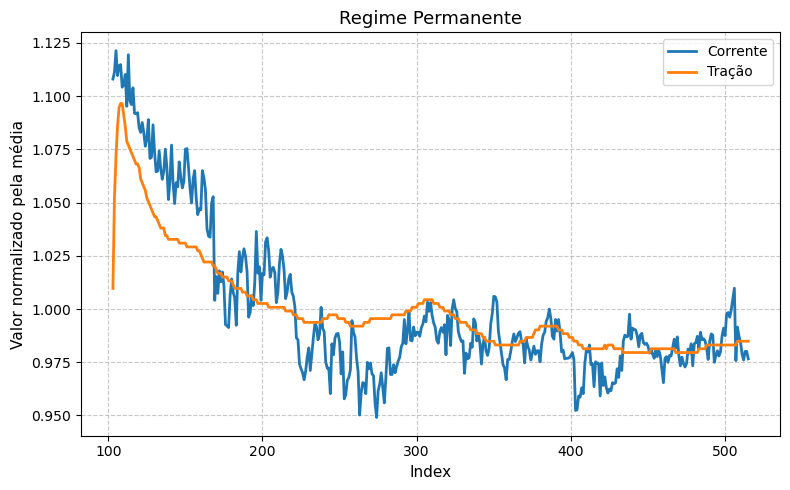

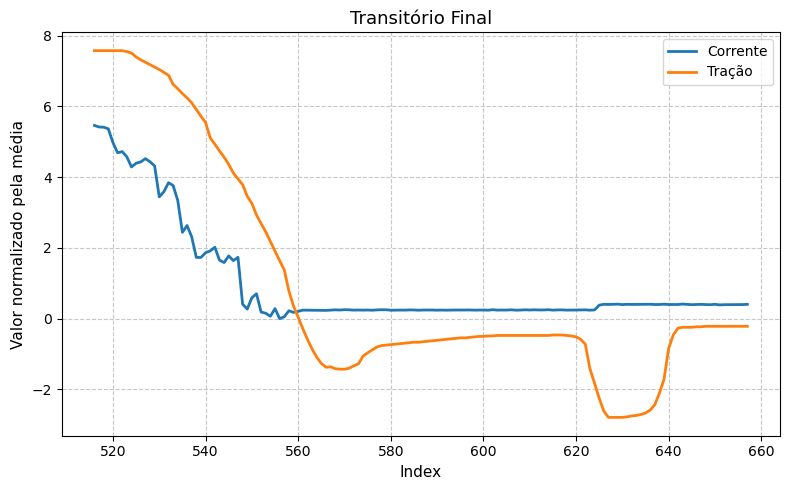

In [122]:
def transitory_stacionary(df):
    
    # Adquire a localização em índice da coluna de "Corrente_A" do dataframe utilizado como argumento
    # Há a soma "+ 1" pois, para a indexação em cada linha através do da função "itertuples()" do pandas
    loc_i = df.columns.get_loc("Corrente_A") + 1

    # Obtém os intervalos em que estão localizados 30% e 70% dos valores de corrente armazenados
    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)

    # Cria um novo dataframe cujos valores são aqueles entre q1 e q3, ou seja, 40% dos dados centrais
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    # "Flag" criada para indicar que o ponto que termina o transitório inicial e inicia a seção do regime permanente já foi identificado
    flag_stac = False

    # "Flag" para indicar que o ponto que termina o regime permanente e inicia o transitório final ainda não foi identificado
    flag_transitory_1 = True

    # Valor em que o transitório 2 será armazenado
    transitory_2 = None

    # Média do dataframe com os 40% dos dados centrais
    mean = df_40["Corrente_A"].mean()
    
    # Para cada linha (row) no dataframe, numerando as iterações pela variável "idx"...
    for idx, row in enumerate(df.itertuples()):

        # Verifica se o valor de corrente está entre 99% e 130% da média, além de verificar se flag_transitory_1 == True
        if ((np.abs(row[loc_i]) >= 0.99*mean) & (np.abs(row[loc_i]) <= 1.3*mean) & flag_transitory_1):
            
            # O valor de índice atual somado a 10 posições é armazenado na variável "transitory_1"
            transitory_1 = idx + 12

            # As flags são atualizadas
            flag_stac = True
            flag_transitory_1 = False

        # Se a flag_stac == True... 
        if flag_stac:

            # Realiza a verificação se o valor atual de corrente está entre 30 e 82% da média
            if ((np.abs(row[loc_i]) <= 0.82*mean) & (np.abs(row[loc_i]) >= 0.3*mean)):
                
                # Armazena o índice atual subtraído de 8 posições na variável transitory_2
                transitory_2 = idx - 8
                break

    # O dataframe referente ao transitório inicial é definido
    df_0 = df.iloc[:transitory_1]

    # Se for for identificado o transitório final...
    if transitory_2 != None:

        # O dataframe do regime permanente é definido entre as duas posições armazenadas anteriormente
        df_1 = df.iloc[transitory_1:transitory_2]

        # O dataframe do transitório final é definido
        df_2 = df.iloc[transitory_2:]
    
    # Caso contrário...
    else:
        
        # O dataframe do regime permanente é definido entre a posição do "transitory_1" até o final do dataframe
        df_1 = df.iloc[transitory_1:]
        # O dataframe do transitório final é definido como "None" por não ter sido identificado
        df_2 = None

    return df_0, df_1, df_2

df_ex = pd.read_excel(os.path.join(quebradaFolder, "helicequebrada_6.xlsx"))
df0, df1, df2 = transitory_stacionary(df_ex)

plot_technical(df_ex.index, 
    [df_ex["Corrente_A"]/df_ex["Corrente_A"].mean(), df_ex["Celula1_Kgf"]/df_ex["Celula1_Kgf"].mean()], 
    title="DataFrame completo", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração"])
plot_technical(df0.index, 
    [df0["Corrente_A"]/df0["Corrente_A"].mean(), df0["Celula1_Kgf"]/df0["Celula1_Kgf"].mean()], 
    title="Transitório Inicial", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração"])
plot_technical(df1.index, 
    [df1["Corrente_A"]/df1["Corrente_A"].mean(), df1["Celula1_Kgf"]/df1["Celula1_Kgf"].mean()], 
    title="Regime Permanente", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração"])
plot_technical(df2.index, 
    [df2["Corrente_A"]/df2["Corrente_A"].mean(), df2["Celula1_Kgf"]/df2["Celula1_Kgf"].mean()], 
    title="Transitório Final", 
    xlabel="Index", 
    ylabel="Valor normalizado pela média", 
    labels=["Corrente", "Tração"])

Os parâmetros considerados relevantes para a análise do sistema foram organizados por meio da <span style="color:green;">classe statisticsParams</span>, definida na célula abaixo. O objetivo é que cada objeto seja um tipo de operação, armazenando informações da média, mediana, moda, valor máximo, valor mínimo, desvio padrão, assimetria e excesso de curtose para cada coluna presente no DataFrame da operação respectiva. Além desses valores, é possível armazenar também a quantidade de dados presentes para os transitórios e regime permanente.

In [123]:
class statisticsParams:
    def __init__(self, name = None, df = None, tr1_qty = None, regime_qty = None, tr2_qty = None):
        
        # Inicialização dos dicionários vazios
        mean = {}
        median = {}
        max = {}
        min = {}
        desv_padr = {}
        skew = {}
        kurtosis = {}
        mode = {}

        # Caso haja um argumento de df não nulo:
        if df is not None:

            # Adquire a lista com o cabeçalho do dataframe
            header = df.columns.to_list()    

            # Para cada elemento na lista do cabecalho...
            for h in header:
                mean[h] = df[h].mean()  # Adquire o valor da média para o parâmetro atual
                median[h] = df[h].median()  # Adquire o valor da mediana para o parâmetro atual
                max[h] = df[h].max()    # Adquire o valor máximo para o parâmetro atual
                min[h] = df[h].min()    # Adquire o valor mínimo para o parâmetro atual
                desv_padr[h] = st.stdev(df[h])  # Adquire o desvio padrão para o parâmetro atual
                skew[h] = df[h].skew()  # Adquire a assimetria entre os dados para o parâmetro atual
                kurtosis[h] = df[h].kurtosis()  # Adquire o excesso de curtose para o parâmetro atual
                mode[h] = st.mode(df[h])    # Adquire a moda para o parâmetro atual

            # Armazenamento do que foi medido nos parâmetros do objeto
            self.name = name
            self.header = header
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            # Armazenamento nos parâmetros do objeto da quantidade de dados para cada regime de operação, sendo esses argumentos da classe.
            self.tr1_qty = tr1_qty
            self.regime_qty = regime_qty
            self.tr2_qty = tr2_qty

        # Caso o argumento "df" seja "None", os parâmetros da função se mantém como definidos no início, strings vazias ou zeros
        else:
            self.name = ""
            self.mean = mean
            self.median = median
            self.max = max
            self.min = min
            self.desv_padr = desv_padr
            self.skew = skew
            self.kurtosis = kurtosis
            self.mode = mode

            self.tr1_qty = 0
            self.regime_qty = 0
            self.tr2_qty = 0

Com o objetivo de visualizar as informações relevantes, a <span style="color:green;">função "stats_dataFrame"</span> abaixo foi definida, cujo argumento é um objeto da classe statisticParams, definida anteriormente. A função irá imprimir no terminal os valores armazenados no objeto para cada parâmetro (coluna) do DataFrame inicial.

Nota-se que, antes de realizar a impressão, há a organização dos valores em um DataFrame, cujas colunas são definidas pelas chaves (Parametro, Media, Mediana...) e as linhas são definidas pela iteração do cabeçalho obtido pelo objeto dado como entrada na função, obtendo os valores referentes à cada coluna.

Ao final, há a impressão da quantidade de dados para cada transitório e regime permanente, também.

In [124]:
def stats_dataFrame(class_param):
    
    resumo = pd.DataFrame({
            "Parametro": (h for h in class_param.header),
            "Media": (class_param.mean[h] for h in class_param.header),
            "Mediana": (class_param.median[h] for h in class_param.header),
            "Moda": (class_param.mode[h] for h in class_param.header),
            "Maximo": (class_param.max[h] for h in class_param.header),
            "Minimo": (class_param.min[h] for h in class_param.header),
            "Desvio padrao": (class_param.desv_padr[h] for h in class_param.header),
            "Assimetria": (class_param.skew[h] for h in class_param.header),
            "Excesso de curtose": (class_param.kurtosis[h] for h in class_param.header)
        })
    
    print("Transitorio 1, quantidade de dados = ", class_param.tr1_qty)
    print("Regime, quantidade de dados = ", class_param.regime_qty)
    print("Transitorio 2, quantidade de dados = ", class_param.tr2_qty)
    print(resumo)

A <span style="color:green;">função "concatDataframes"</span> abaixo foi feita com o objetivo de realizar o concatenamento de uma lista de DataFrames, que é o argumento da função. Em situações de múltiplas aquisições de dados referentes a uma única operação, pode ser útil e importante para a análise do comportamento do sistema obter um DataFrame resultante.

É importante ressaltar que, quando houver a necessidade de concatenar dados adquiridos, somente dados em regime permanente serão concatenados e analisados, a princípio, como é evidenciado nos passos posteriores deste notebook.

In [125]:
def concatDataframes(df_list):
    for i, df in enumerate(df_list):
        if i != 0:
            df_tot = pd.concat([df_tot, df], ignore_index=True)
        else:
            df_tot = df
    
    return df_tot

## <span style="color:green;">Estatística Descritiva e Análise Interpretativa </span>

O <span style="color:green;">algoritmo abaixo foi desenvolvido </span>com o objetivo de acessar os diretórios das operações e apresentar os dados relevantes a partir de funções definidas anteriormente. Os dados dispostos ao executar o algoritmo são referentes ao intervalo em regime permanente, com exceção da quantidade de dados, que há a inclusão para os transitórios e para o regime permanente. 

In [126]:
for fold in folders: # Para cada chave definida no dicionário "folders" definido anteriormente...

    # Criação de listas vazias.
    df0s = []   # Lista de dataframes do transitório inicial
    df1s = []   # Lista de dataframes do regime permanente
    df2s = []   # Lista de dataframes do transitório final
   
    tr1_tot_qty = 0 # Quantidade de dados no transitório inicial
    tr2_tot_qty = 0 # Quantidade de dados no regime permanente
    regime_tot_qty = 0  # Quantidade de pontos no transitório final

    print("")
    print("=============", fold, "=============")   # Imprime o título da operação atual (normal, desbalanceada, quebrada ou invertida)

    # Armazena todos os diretórios presentes na pasta atual em uma lista chamada "files_temp"
    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")] 

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame "df_i" da lista de DataFrames da pasta atual, numerando a partir da variável "i"
    for i, df_i in enumerate(dfs):

        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")
       
        df_0, df_1, df_2 = transitory_stacionary(df_i)  # Segmenta o dataframe "df_i" nos dataframes de transitórios (df_0 e df_2) e regime permanente (df_1)

        # Realiza o somatório da quantidade de dados presentes em cada planilha de uma operação
        tr1_tot_qty += len(df_0)
        regime_tot_qty += len(df_1)
        tr2_tot_qty += len(df_2)

        # Armazena os dataframes da operação atual nas listas definidas anteriormente
        df1s.append(df_1)

    # Concatena os dataframes, sendo df1_tot o dataframe total em regime permanente da operação atual
    df1_tot = concatDataframes(df1s)
    
    # Cria o objeto "op_tot", referente à classe "statisticsParams" definida anteriormente, a partir dos dados obtidos nessa célula
    op_tot = statisticsParams(fold, df1_tot, tr1_qty=tr1_tot_qty, regime_qty=regime_tot_qty, tr2_qty=tr2_tot_qty)

    # Utiliza a função "stats_dataFrame" para imprimir os valores estatísticos relevantes para a análise atual no terminal
    stats_dataFrame(op_tot)

    # Armazena o cabeçalho do dataframe na variável "header"
    header = df1_tot.columns.to_list()

    #subplot_histogram(df1_tot, header)
    #plot_technical(df1_tot.index, df1_tot["Celula1_Kgf"], title="DataFrame completo", xlabel="Index", ylabel="Valor normalizado pela média", labels=["Tração"])


============= normal =============
Transitorio 1, quantidade de dados =  377
Regime, quantidade de dados =  1243
Transitorio 2, quantidade de dados =  274
     Parametro        Media   Mediana      Moda     Maximo     Minimo  \
0  Celula1_Kgf  -640.777152  -640.000  -666.000  -588.0000  -785.0000   
1  Celula2_Kgf  2581.093323  2719.000  2863.000  3047.0000  1896.0000   
2     Tensao_V    13.445020    13.550    13.760    14.2500    12.5300   
3   Corrente_A    31.321601    30.150    28.890    38.1600    24.4600   
4   Potencia_W   421.947599   407.048   513.248   523.1736   327.5194   

   Desvio padrao  Assimetria  Excesso de curtose  
0      27.917974   -0.241440            0.284153  
1     283.357491   -0.352143           -1.304569  
2       0.353271   -0.426580           -0.828513  
3       3.239374    0.690483           -0.811899  
4      52.299719    0.506768           -1.080882  

============= desbalanceada =============
Transitorio 1, quantidade de dados =  509
Regime, quanti

### <span style="color:green;">Análise dos resultados dispostos </span>

A operação de hélice desbalanceada: 
- Retornou um valor maior de tração (Celula1_Kgf), em média, do que as outras operações, visto que, de acordo com a montagem dos componentes na bancada, sinal negativo indica tração para a célula de carga 1. Mesmo estando desbalanceada em massa, a hélice selecionada para realizar esse ensaio pode ter apresentado melhores características aerodinâmicas do que as outras, apesar de serem do mesmo modelo. 
- Nota-se uma maior dispersão dos valores conforme indicado pelo desvio padrão, o que é esperado, devido à assimetria de inércia no plano perpendicular ao diâmetro da hélice. 
- O valor negativo de "excesso de curtose" apresenta a tendência a uma curva platicúrtica para todos os parâmetros, indicando a ausência de valores extremos e caudas pesadas. Utilizando essa informação em conjunto com o valor de dispersão, implica em um comportamento muito variável mas sem picos isolados ou peso em uma das caudas.
- Ademais, para esse mesmo caso, é possível observar uma média de carga de torque (Celula2_Kgf) mais elevada quando comparado com as outras operações, o que é esperado pelo mesmo motivo do caso da tração, visto que a assimetria de inércia influencia no resultado das duas cargas analisadas. Durante o movimento rotacional da hélice, o desbalanceamento pode contribuir para a alternância entre eventos de alta carga aerodinâmica e baixa carga aerodinâmica, o que resulta em uma maior dispersão dos valores de torque. 

A operação normal: 
- Apresentou maior valor médio de tração, com exceção do caso de hélice desbalanceada, o que era esperado, visto que a operação com hélice quebrada deve apresentar queda de eficiência (devido à perda parcial de uma das pás) e a operação de rotação invertida deve indicar inversão do sinal, como é possível ver na disposição dos valores acima. 
- Em relação à corrente e potência, nota-se que os menores valores médios foram da operação normal, visto que as falhas podem gerar sobrecarga no sistema, como perda aerodinâmica e picos e alternâncias de carga, necessitando de uma maior entrega de potência e, consequentemente, corrente.
- O excesso de curtose observado foi baixo ou menor que zero, demonstrando que não houve a presença de picos e/ou vales extremos nesse tipo de operação, visto que não eram esperadas falhas.

Já a operação de hélice quebrada:
- Apesar de não conter grandes desvios quando comparado aos outros tipos de operação, apresentou queda brusca de tração devido à perda parcial de uma das pás, corroborando em uma alta perda aerodinâmica. 
- Por ser uma hélice do tipo tripá, a perda parcial de uma das pás pode ter apresentado menor influência na distribuição de inércia do que o caso da hélice desbalanceada, visto que, para o segundo caso, o desbalanceamento foi realizado pelo acúmulo de massa na extremidade de uma das pás, gerando uma grande distância do centro de massa inicial. Essa possível menor assimetria contribui para o baixo desvio padrão.

Por fim, a operação invertida:
- Gerou compressão na célula de carga, dado a inversão de sinal comparado aos casos anteriores. 
- Nota-se que os valores de corrente foram distribuidos de forma semelhante ao caso de operação normal, porém, em uma região com valores superiores, gerando maiores valores de potência, além de um excesso de curtose um pouco superior. Por estar sendo submetida à um movimento contrário ao que deveria ser realizado, o perfil aerodinâmico observado apresenta baixa eficiência, implicando en um maior arrasto nesse tipo de operação, o que gera uma sobrecarga no sistema, levando a uma maior corrente média. 

### <span style="color:green;">Repetibilidade das amostras</span>
As análises realizadas anteriormente foram feitas a partir da concatenação de todas as amostras obtidas para cada tipo de operação. Visando observar a repetibilidade entre amostras, a função abaixo foi desenvolvida.

A função "individualMetrics" apresenta como argumento uma lista, que deve conter todos os DataFrames de uma operação respectiva. Para cada parâmetro, a função obtém a média das médias e o desvio padrão das médias. Dessa forma, apresenta-se a variabilidade entre as métricas de uma mesma operação.

In [127]:
def individualMetrics(df_list):

    header = df_list[0].columns.to_list()
    mean_of_means = []
    stdev_of_means = []
    i = 0
    for h in header:
        mean_list = []
        for df in df_list:
            mean_list.append(df[h].mean())
            
        mean_of_means.append(st.mean(mean_list))
        stdev_of_means.append(st.stdev(mean_list))


    data_frame = pd.DataFrame({
        "Parameter": header,
        "Media": mean_of_means,
        "Desvio Padrao": stdev_of_means
    })

    print(data_frame)            

De modo semelhante ao que foi realizado anteriormente, o algoritmo abaixo realiza a verificação de todas as operações por meio do uso da função definida acima.

In [128]:
for fold in folders:
    df1s = []
   
    tr1_tot_qty = 0
    tr2_tot_qty = 0
    regime_tot_qty = 0

    print("")
    print("=============", fold, "=============")

    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")]

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame da lista de DataFrames da pasta atual
    for i, df_i in enumerate(dfs):

        df_i = df_i.drop(columns="Celula3_Kgf")
        df_i = df_i.drop(columns="Tempo")
        df_i = df_i.drop(columns="RPM")
       
        df_0, df_1, df_2 = transitory_stacionary(df_i)
        df1s.append(df_1)

    print(len(df1s))
    individualMetrics(df1s)


============= normal =============
3
     Parameter        Media  Desvio Padrao
0  Celula1_Kgf  -640.714164      21.774961
1  Celula2_Kgf  2586.675625     279.135012
2     Tensao_V    13.444487       0.311090
3   Corrente_A    31.322877       3.475990
4   Potencia_W   421.952348      56.750044

============= desbalanceada =============
3
     Parameter        Media  Desvio Padrao
0  Celula1_Kgf  -873.582081      95.890986
1  Celula2_Kgf  3010.687832     589.977110
2     Tensao_V    13.003633       0.385714
3   Corrente_A    37.951517       6.491930
4   Potencia_W   495.326127     100.086711

============= quebrada =============
5
     Parameter        Media  Desvio Padrao
0  Celula1_Kgf  -548.440711      50.485626
1  Celula2_Kgf  2458.624177     133.555988
2     Tensao_V    13.301556       0.342874
3   Corrente_A    33.479146       2.338896
4   Potencia_W   445.531097      34.923303

============= invertida =============
2
     Parameter        Media  Desvio Padrao
0  Celula1_Kgf   77

Nota-se que a operação de hélice desbalanceada apresentou menor repetibilidade das médias, em geral, do que o restante das operações, como esperado conforme citado anteriormente, seguido pela operação normal, hélice quebrada e rotação invertida. Esperava-se que o caso de hélice quebrada apresentasse maior dispersão de valores entre as médias do que as operações normal e de rotação invertida. Essa expectativa foi estabelecida ao assumir que a perda de uma das pás iria corroborar em uma assimetria de inércia, mesmo que menor em relação ao caso de hélice desbalanceada.

Devido à falta de instrumentos para mensuramento de distribuição de massa resultante das hélices, esse parâmetro não foi verificado, portanto, por mais que houvesse a perda parcial de uma das pás no experimento, por ser uma hélice do tipo tripá, existe a possibilidade de que a assimetria de inércia tenha sido desprezível.

Apesar da suposição citada na frase acima, garantiu-se que a hélice utilizada na operação de hélice desbalanceada apresentasse quantidade excessiva de massa acumulada na ponta de uma das pás. O seu desbalanceamento foi evidenciado ao inserí-la em um eixo, permitindo o teste empírico de seu movimento rotacional.